# Whole-pipeline cascade evaluation (nested, repeated splits)

This notebook evaluates the **entire prediction cascade** (`Pipeline.run` in
`phishing_engine/core/pipeline.py`) end-to-end and characterises how its decision policy trades
detection quality against collection cost.

Stages run in order `url -> content -> domain`. Each stage has a symmetric **deferral band**
`[0.5 - delta, 0.5 + delta]`: a probability **outside** the band is confident either way, so the stage
decides on its own and the remaining stages (and their live collection) are skipped; a probability
**inside** the band escalates. If no stage exits, the verdict comes from **aggregating** every
collected probability (`mean`/`max`/`median` per `decision.fallback_aggregation`) against the fixed
`FALLBACK_DECISION_BOUNDARY` (0.5).

**Evaluation protocol.** Every choice the engine makes -- which classifier each stage uses, which
aggregation rule fuses them, and the per-stage margins -- is selected on a **validation** fold and
then scored **once** on an untouched **test** fold, with the whole procedure repeated over a rotation
of domain-grouped folds and several seeds. Tables and figures therefore report a mean and a standard
deviation over runs rather than a single split, and the cascade is compared against full fusion with a
paired test rather than by comparing decimals.

## Setup

In [19]:
import os, sys, time, warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import tldextract                       # registered-domain (eTLD+1) grouping for the split

# Make the project importable when the kernel's cwd is the repo root.
sys.path.insert(0, os.path.abspath("."))

import phishing_engine.stages  # noqa: F401  (registers url/domain/content stages)
from phishing_engine.core.config import load_config
from phishing_engine.core.registry import get_stage
from phishing_engine.core.pipeline import Pipeline, PipelineContext, FALLBACK_DECISION_BOUNDARY
from phishing_engine.storage.mongo import MongoStore

from sklearn.model_selection import StratifiedGroupKFold
from scipy.stats import binomtest   # exact McNemar on the discordant pairs
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

# Model zoo (mirrors model_evaluation.ipynb). sklearn's Pipeline is aliased to SkPipeline
# so it does not shadow phishing_engine's cascade Pipeline imported above.
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
print("imports ok; FALLBACK_DECISION_BOUNDARY =", FALLBACK_DECISION_BOUNDARY)

imports ok; FALLBACK_DECISION_BOUNDARY = 0.5


### Parameters

In [20]:
CONFIG_PATH = "config/pipeline.json"
# Cap on labeled docs (0 = all). Override with PHISH_EVAL_LIMIT for a quick smoke run.
LIMIT = int(os.environ.get("PHISH_EVAL_LIMIT", "0"))

# --- nested, repeated protocol ----------------------------------------------------------------
# Outer StratifiedGroupKFold over registered domains (eTLD+1) -> one fold is TEST; an inner fold of
# the remainder is VALIDATION. Nothing is ever selected on TEST.
N_OUTER, N_INNER = 5, 4              # -> 60/20/20 train/validation/test, grouped by eTLD+1
SEEDS       = [42, 7, 2026]          # drives both the split shuffle and every model's random_state
OUTER_FOLDS = [0, 1, 2, 3, 4]        # which outer folds to hold out (all five = a full rotation)
SELECTION_METRIC    = "f1"           # the zoo is ranked by this ON VALIDATION
INCLUDE_SLOW_MODELS = False          # adds SVM (RBF) to the zoo

# --- decision-policy sweeps -------------------------------------------------------------------
AGGREGATIONS = ["mean", "median", "max"]             # fallback fusion rules (chosen on validation)
DELTAS     = np.round(np.linspace(0.0, 0.5, 51), 4)  # shared-margin sweep (the swept figures)
DGRID3     = np.round(np.linspace(0.0, 0.5, 51), 4)  # per-stage margin grid -> 51^3 combos per run
THRESHOLDS = np.round(np.linspace(0.0, 1.0, 101), 4) # legacy one-sided baseline
BUDGETS       = [50, 100, 250, 500, 1000, 2000, 4000]   # expected per-URL latency budgets (ms)
SHIPPED_BUDGET = 250                                    # the budget the engine ships at
SHIPPED_LABEL  = "shipped margins (config/pipeline.json)"
TIE_BREAK = "cheap"   # equal-validation-F1 triples: "cheap" = least cost, "wide" = spend the budget
N_BOOT    = 1000      # domain-grouped bootstrap resamples per run

# --- caches / outputs ---------------------------------------------------------------------------
FEATURE_CACHE_DIR = "feature_cache"      # joint per-URL feature cache (extraction is the slow part)
USE_FEATURE_CACHE = True
FORCE_RECALC      = False
RESULT_CACHE = "eval_results/nested/cache"   # one joblib per (seed, fold) run
FORCE_RERUN  = False                         # True recomputes even when a cached run exists
OUT_DIR = "eval_results/nested"               # tables written by the report cells
FIGDIR  = "eval_results/nested/figs"          # figures (NOT the thesis/paper dirs; see export cell)
os.makedirs(OUT_DIR, exist_ok=True)

print(f"protocol: {N_OUTER}-fold outer / {N_INNER}-fold inner, grouped by eTLD+1 "
      f"-> {len(SEEDS) * len(OUTER_FOLDS)} runs ({len(SEEDS)} seeds x {len(OUTER_FOLDS)} folds)")
print(f"selection on VALIDATION by {SELECTION_METRIC}; margin grid {len(DGRID3)}^3 = "
      f"{len(DGRID3) ** 3} combos per run; budgets {BUDGETS} ms")

protocol: 5-fold outer / 4-fold inner, grouped by eTLD+1 -> 15 runs (3 seeds x 5 folds)
selection on VALIDATION by f1; margin grid 51^3 = 132651 combos per run; budgets [50, 100, 250, 500, 1000, 2000, 4000] ms


### Connect to MongoDB and read the decision policy

The config supplies the labels, the fixed decision boundary, the cascade order and the margins the
engine currently ships (`pipeline.decision` + each stage's `margin`). Under the nested protocol the
**aggregation rule and the per-stage margins are selected on validation** rather than taken from the
config, so the shipped values are carried through as a reference operating point and scored like any
other fixed configuration.

In [21]:
config   = load_config(CONFIG_PATH)
mongo    = config.pipeline.mongo
DECISION = config.pipeline.decision
STAGE_CONFIGS = {s.id: s for s in config.pipeline.stages}
POSITIVE = DECISION.positive_label   # "phish"
NEGATIVE = DECISION.negative_label   # "benign"

print(f"db={mongo.database!r} urls={mongo.collection!r} domains={mongo.domain_collection!r}")
print(f"decision: margin(default)={DECISION.margin} positive={POSITIVE!r} "
      f"negative={NEGATIVE!r} fallback_aggregation={DECISION.fallback_aggregation!r}")
print("per-stage deferral margins:",
      {s.id: s.margin for s in config.pipeline.stages})
try:   # the joint feature cache makes MongoDB optional for a replay-only run
    store = MongoStore(mongo.uri, mongo.database, mongo.collection, mongo.domain_collection)
    print("labeled docs with a domain record:",
          store.count_labeled(require="domain_record", limit=LIMIT))
except Exception as e:
    store = None   # only needed if the feature cache has to be rebuilt
    print(f"[warn] MongoDB unreachable ({e.__class__.__name__}); "
          f"the run will need {FEATURE_CACHE_DIR}/ to be populated")


db='phishing_engine' urls='url_documents' domains='domain_records'
decision: margin(default)=0.4 positive='phish' negative='benign' fallback_aggregation='mean'
per-stage deferral margins: {'url': 0.49, 'content': 0.28, 'domain': 0.1}
labeled docs with a domain record: 10625


## Feature extraction

### Joint per-URL feature extraction

One pass over `iter_labeled(require="domain_record")` (which `$lookup`-joins the domain
record and still carries `raw.content` when present). For each URL we run the **same**
extractors the training/prediction pipelines use and key everything by URL `_id`:

- **url** features from the URL string (always available),
- **domain** features from `raw.domain_record` (identical for every URL of a host),
- **content** features from `raw.content` when the page was collected.

`domain_ok` / `content_ok` record whether a stage produced features; a stage with no
features contributes no probability later (mirroring the cascade's "escalate" path). The
aligned matrices are cached to `feature_cache/` so re-runs skip the slow extraction.

In [22]:
URL_COLS     = STAGE_CONFIGS["url"].feature_columns
CONTENT_COLS = STAGE_CONFIGS["content"].feature_columns   # domain stage has no fixed columns

def _align(df, cols):
    '''Coerce to numeric (bools->0/1); if cols given, add missing + order to them, drop extras.

    Mirrors the coercion in core/training.py so the offline features match training exactly.
    '''
    df = df.replace({True: 1, False: 0})
    if cols:
        for c in cols:
            if c not in df.columns:
                df[c] = 0
        df = df[cols]
    return df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

def _cache_paths(limit):
    suf = f"_lim{limit}" if limit else ""
    base = os.path.join(FEATURE_CACHE_DIR, f"pipeline_joint{suf}")
    return {k: f"{base}_{k}.csv" for k in ("meta", "url", "domain", "content")}

def build_joint_dataset(limit=LIMIT):
    paths = _cache_paths(limit)
    if USE_FEATURE_CACHE and not FORCE_RECALC and all(os.path.exists(p) for p in paths.values()):
        meta = pd.read_csv(paths["meta"])
        url_df, dom_df, con_df = (pd.read_csv(paths[k]) for k in ("url", "domain", "content"))
        print(f"[cache] loaded joint dataset: {len(meta)} URLs  ({FEATURE_CACHE_DIR}/)")
        return meta, url_df, dom_df, con_df

    url_stage = get_stage("url")(STAGE_CONFIGS["url"], None)
    dom_stage = get_stage("domain")(STAGE_CONFIGS["domain"], None)
    con_stage = get_stage("content")(STAGE_CONFIGS["content"], None)

    ids, refs, labels, has_content, dom_ok, con_ok = [], [], [], [], [], []
    url_rows, dom_rows, con_rows = [], [], []
    failed = 0
    t0 = time.perf_counter()
    total = store.count_labeled(require="domain_record", limit=limit)
    it = tqdm(store.iter_labeled(require="domain_record", limit=limit),
              total=total, desc="extracting features", unit="doc")
    for doc in it:
        label = doc.get("label")
        if label not in ("phish", "benign"):
            continue
        ctx = PipelineContext(url=doc.get("url", ""), normalized_url=doc["_id"],
                              domain=doc.get("domain", ""), label=label)
        raw = doc.get("raw") or {}
        try:
            u = url_stage.extract_features(ctx, {})
        except Exception:
            failed += 1
            continue
        try:
            d = dom_stage.extract_features(ctx, dom_stage.build_train_artifacts(doc))
        except Exception:
            d = {}
        if raw.get("content") is not None:
            try:
                c = con_stage.extract_features(ctx, con_stage.build_train_artifacts(doc))
            except Exception:
                c = {}
            hc = True
        else:
            c, hc = {}, False

        ids.append(doc["_id"]); refs.append(raw.get("domain_record_ref")); labels.append(label)
        has_content.append(hc); dom_ok.append(bool(d)); con_ok.append(hc and bool(c))
        url_rows.append(u); dom_rows.append(d); con_rows.append(c)

    print(f"extracted {len(ids)} URLs in {time.perf_counter() - t0:.0f}s "
          f"({failed} url-extraction failures skipped)")

    meta = pd.DataFrame({"_id": ids, "domain_ref": refs, "_label": labels,
                         "has_content": has_content, "domain_ok": dom_ok, "content_ok": con_ok})
    url_df = _align(pd.DataFrame(url_rows), URL_COLS)
    dom_df = _align(pd.DataFrame(dom_rows), None)          # keep extractor-produced columns
    con_df = _align(pd.DataFrame(con_rows), CONTENT_COLS)

    if USE_FEATURE_CACHE:
        os.makedirs(FEATURE_CACHE_DIR, exist_ok=True)
        meta.to_csv(paths["meta"], index=False)
        url_df.to_csv(paths["url"], index=False)
        dom_df.to_csv(paths["domain"], index=False)
        con_df.to_csv(paths["content"], index=False)
        print(f"[cache] saved joint dataset -> {FEATURE_CACHE_DIR}/")
    return meta, url_df, dom_df, con_df

meta, url_df, dom_df, con_df = build_joint_dataset()

# Positional alignment across every frame (index == row position).
meta   = meta.reset_index(drop=True)
url_df = url_df.reset_index(drop=True)
dom_df = dom_df.reset_index(drop=True)
con_df = con_df.reset_index(drop=True)
y = (meta["_label"].to_numpy() == POSITIVE).astype(int)

print("shapes:", {"meta": meta.shape, "url": url_df.shape,
                  "domain": dom_df.shape, "content": con_df.shape})
print(f"phish={int(y.sum())} benign={int((y == 0).sum())} | "
      f"with content={int(meta['has_content'].sum())} | "
      f"domain_ok={int(meta['domain_ok'].sum())} content_ok={int(meta['content_ok'].sum())}")

[cache] loaded joint dataset: 10306 URLs  (feature_cache/)
shapes: {'meta': (10306, 6), 'url': (10306, 39), 'domain': (10306, 136), 'content': (10306, 111)}
phish=4823 benign=5483 | with content=9618 | domain_ok=10306 content_ok=9618


## Nested evaluation protocol (train / validation / test, repeated)

Everything from here on runs under a **nested, domain-grouped protocol**.

* **outer** `StratifiedGroupKFold(5)` over registered domains (eTLD+1) -> one fold is **TEST**;
* **inner** `StratifiedGroupKFold(4)` over the remaining rows -> one fold is **VALIDATION**;
* models are fitted on **TRAIN**, every choice (classifier per stage, aggregation rule, per-stage
  margins) is made on **VALIDATION**, and the resulting *fixed* configuration is scored **once** on
  **TEST**;
* the whole procedure is repeated over the 5 outer folds x `SEEDS`, so every number below carries a
  standard deviation instead of resting on one split.

Models are fitted on TRAIN only and never refitted on TRAIN+VALIDATION, so the margins are
calibrated on exactly the models that get scored on TEST.

In [23]:
# group key = registered domain (eTLD+1); offline (bundled suffix snapshot, no network).
_tld = tldextract.TLDExtract(suffix_list_urls=())

def _registered_domain(domain_ref, _id):
    host = domain_ref.split("|", 1)[0] if isinstance(domain_ref, str) and domain_ref else ""
    if not host:
        return str(_id)                       # fall back to the URL id if no host
    return _tld(host).registered_domain or host

groups = np.array([_registered_domain(r, i)
                   for r, i in zip(meta["domain_ref"], meta["_id"])])
print(f"registered-domain groups: {len(set(groups))}  (from {meta['_id'].nunique()} URLs)")


def nested_split(seed, outer_fold, n_outer=N_OUTER, n_inner=N_INNER):
    '''(train_idx, val_idx, test_idx) disjoint by registered domain.

    Outer fold `outer_fold` is TEST; the first inner fold of the remainder is VALIDATION.
    With n_outer=5 / n_inner=4 this is a 60/20/20 domain-grouped split.
    '''
    idx = np.arange(len(y))
    outer = StratifiedGroupKFold(n_splits=n_outer, shuffle=True, random_state=seed)
    folds = [te for _, te in outer.split(idx, y, groups)]
    test_idx = folds[outer_fold]
    dev_idx = np.concatenate([f for i, f in enumerate(folds) if i != outer_fold])

    inner = StratifiedGroupKFold(n_splits=n_inner, shuffle=True, random_state=seed + 1000)
    inner_folds = [te for _, te in inner.split(dev_idx, y[dev_idx], groups[dev_idx])]
    val_idx   = dev_idx[inner_folds[0]]
    train_idx = dev_idx[np.concatenate(inner_folds[1:])]

    gt, gv, gs = (set(groups[i]) for i in (train_idx, val_idx, test_idx))
    assert not (gt & gv) and not (gt & gs) and not (gv & gs), "domain leak across splits!"
    for nm, i in (("train", train_idx), ("val", val_idx), ("test", test_idx)):
        assert set(np.unique(y[i])) == {0, 1}, f"{nm} split is single-class; adjust seed/LIMIT"
    return np.sort(train_idx), np.sort(val_idx), np.sort(test_idx)

RUNS = [(s, f) for s in SEEDS for f in OUTER_FOLDS]

registered-domain groups: 4258  (from 10306 URLs)


### Per-stage model zoo (fitted on TRAIN, ranked on VALIDATION)

The zoo is unchanged (it mirrors `model_evaluation.ipynb`); what changed is *where* the winner is
chosen. Each stage is scored on its own prediction unit: `url` and `content` per URL, `domain` per
registered host (domain features are identical for every URL of a host, so scoring them per URL
would weight big hosts many times over).

In [24]:
def make_models(seed):
    '''Candidate models per stage -- same zoo as model_evaluation.ipynb.'''
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
    models = {
        "Logistic Regression": SkPipeline([("scaler", StandardScaler()),
                                           ("clf", LogisticRegression(max_iter=1000, random_state=seed))]),
        "Decision Tree":     DecisionTreeClassifier(random_state=seed),
        "Random Forest":     RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=seed),
        "Extra Trees":       ExtraTreesClassifier(n_estimators=300, n_jobs=-1, random_state=seed),
        "Gradient Boosting": GradientBoostingClassifier(random_state=seed),
        "KNN":               SkPipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
        "XGBoost":           XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                                           subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
                                           tree_method="hist", n_jobs=-1, random_state=seed),
        "LightGBM":          LGBMClassifier(n_estimators=400, learning_rate=0.05, n_jobs=-1,
                                            random_state=seed, verbose=-1),
    }
    if INCLUDE_SLOW_MODELS:
        models["SVM (RBF)"] = SkPipeline([("scaler", StandardScaler()),
                                          ("clf", SVC(kernel="rbf", probability=True, random_state=seed))])
    return models

def phish_proba(model, X):
    '''P(phish) column, located via model.classes_ (labels are 1=phish / 0=benign).'''
    idx = list(model.classes_).index(1)
    return model.predict_proba(X)[:, idx]

def _dedup_domain(idx):
    '''Rows + labels for one row per domain_ref (features identical within a host;
    phish if any URL of the ref is phish) -- matches collect_training_data.'''
    rows, labels = [], []
    for ref, sub in meta.iloc[idx].groupby("domain_ref"):
        ok = sub.index[sub["domain_ok"].to_numpy()]
        if len(ok) == 0:
            continue                                   # this domain produced no features
        rows.append(int(ok[0]))                        # features identical within a domain
        labels.append(1 if (sub["_label"] == POSITIVE).any() else 0)
    return np.array(rows, dtype=int), np.array(labels)

def stage_matrices(stage, train_idx, eval_idx):
    '''(X_train, y_train, X_eval, y_eval) for one stage, on its prediction unit.'''
    if stage == "url":
        return url_df.iloc[train_idx], y[train_idx], url_df.iloc[eval_idx], y[eval_idx]
    if stage == "content":
        ok = meta["content_ok"].to_numpy()
        tr, ev = train_idx[ok[train_idx]], eval_idx[ok[eval_idx]]
        return con_df.iloc[tr], y[tr], con_df.iloc[ev], y[ev]
    if stage == "domain":
        tr, ytr = _dedup_domain(train_idx)
        ev, yev = _dedup_domain(eval_idx)
        return dom_df.iloc[tr], ytr, dom_df.iloc[ev], yev
    raise ValueError(stage)

def _score(y_true, proba):
    '''Threshold-independent (PR-AUC, ROC-AUC) + 0.5-boundary metrics for one model.'''
    preds = (proba >= 0.5).astype(int)
    multi = len(np.unique(y_true)) > 1
    return {"pr_auc":    average_precision_score(y_true, proba) if multi else float("nan"),
            "roc_auc":   roc_auc_score(y_true, proba) if multi else float("nan"),
            "f1":        f1_score(y_true, preds, zero_division=0),
            "precision": precision_score(y_true, preds, zero_division=0),
            "recall":    recall_score(y_true, preds, zero_division=0),
            "accuracy":  accuracy_score(y_true, preds)}

def fit_and_select(stage, train_idx, val_idx, test_idx, seed):
    '''Fit every zoo model on TRAIN, rank by SELECTION_METRIC on VALIDATION, report all on TEST.

    The TEST columns are reported for the whole zoo (that is the per-stage comparison table) but
    are never used to choose the winner.
    '''
    Xtr, ytr, Xva, yva = stage_matrices(stage, train_idx, val_idx)
    _, _, Xte, yte     = stage_matrices(stage, train_idx, test_idx)
    rows, fitted = [], {}
    for name, model in make_models(seed).items():
        t0 = time.perf_counter()
        try:
            model.fit(Xtr, ytr)
        except Exception as e:
            print(f"  [skip] {stage}/{name}: {e}")
            continue
        va, te = _score(yva, phish_proba(model, Xva)), _score(yte, phish_proba(model, Xte))
        rows.append({"stage": stage, "model": name, "fit_sec": time.perf_counter() - t0,
                     **{f"val_{k}": v for k, v in va.items()},
                     **{f"test_{k}": v for k, v in te.items()}})
        fitted[name] = model
    table = pd.DataFrame(rows).sort_values(f"val_{SELECTION_METRIC}", ascending=False).reset_index(drop=True)
    best = table.iloc[0]["model"]
    table["selected"] = table["model"] == best
    return table, fitted[best], best

### Cascade replay (vectorised, parity-checked against the production cascade)

`Replay` holds one split's per-URL stage probabilities (`NaN` where a stage has no evidence, e.g. a
URL whose page fetch failed) and replays the **two-sided deferral-band cascade** over them: a stage
whose `P(phish)` lands **outside** its band `[0.5 - delta, 0.5 + delta]` is confident either way and
decides on its own; a probability **inside** the band escalates. If no stage exits, the verdict comes
from aggregating every collected probability against the fixed `FALLBACK_DECISION_BOUNDARY`.

The vectorised form is what makes a 51^3 margin grid tractable per run; the cell asserts it is exactly
equal to a per-URL replay through the production `Pipeline._build_result`, so the semantics are the
engine's, not a re-implementation.

In [25]:
# --- per-stage mean TOTAL latency (measured by latency_evaluation.ipynb) ---
LAT_MS = (pd.read_csv("eval_results/latency_summary.csv")
            .query("phase == 'total'").set_index("stage")["mean_ms"].to_dict())
CASCADE_ORDER = [s.id for s in config.pipeline.stages if s.enabled]
EXIT_POINTS   = [*CASCADE_ORDER, "fallback"]
print("cascade order:", CASCADE_ORDER)
print("per-stage mean total latency (ms):", {k: round(LAT_MS[k], 1) for k in CASCADE_ORDER})

_replay = Pipeline(stages=[], decision=DECISION)
_ctx    = PipelineContext(url="", normalized_url="", domain="")
BOUNDARY = FALLBACK_DECISION_BOUNDARY

def prf1(verdict, y_bool):
    tp = int((verdict & y_bool).sum()); fp = int((verdict & ~y_bool).sum())
    fn = int((~verdict & y_bool).sum())
    p = tp / (tp + fp) if (tp + fp) else 0.0
    r = tp / (tp + fn) if (tp + fn) else 0.0
    return p, r, (2 * p * r / (p + r) if (p + r) else 0.0)

def confusion_metrics(verdict, y_bool):
    tp = int((verdict & y_bool).sum()); fp = int((verdict & ~y_bool).sum())
    fn = int((~verdict & y_bool).sum()); tn = int((~verdict & ~y_bool).sum())
    p, r, f = prf1(verdict, y_bool)
    return {"precision": p, "recall": r, "f1": f, "accuracy": (tp + tn) / max(tp + fp + fn + tn, 1),
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "fpr": fp / max(fp + tn, 1), "fnr": fn / max(tp + fn, 1)}


class Replay:
    '''One split's per-URL stage probabilities + the banded-cascade replay over them.'''

    def __init__(self, Pu, Pc, Pd, y_true):
        self.Pu, self.Pc, self.Pd = Pu, Pc, Pd
        self.y = y_true.astype(bool)
        self.has_c, self.has_d = ~np.isnan(Pc), ~np.isnan(Pd)
        self.stack = np.vstack([Pu, Pc, Pd])
        self.Lu, self.Lc, self.Ld = (LAT_MS.get(s, 0.0) for s in ("url", "content", "domain"))

    # ---- fusion ---------------------------------------------------------------------------
    def fallback(self, aggregation):
        agg = {"max": np.nanmax, "median": np.nanmedian}.get(aggregation, np.nanmean)
        return agg(self.stack, axis=0) >= BOUNDARY

    def full_pass_latency(self):
        return float((self.Lu + self.has_c * self.Lc + self.has_d * self.Ld).mean())

    def single_stage(self, stage):
        '''That stage alone at the 0.5 boundary, on the URLs where it has evidence.'''
        P, has = {"url": (self.Pu, np.ones(len(self.Pu), bool)),
                  "content": (self.Pc, self.has_c), "domain": (self.Pd, self.has_d)}[stage]
        return np.where(has, np.nan_to_num(P) >= BOUNDARY, False)

    # ---- two-sided deferral band ------------------------------------------------------------
    def band(self, du, dc, dd, aggregation="mean", fb=None, want_exits=False):
        '''(verdict, mean latency ms, exit points) for one per-stage margin triple.'''
        fb = self.fallback(aggregation) if fb is None else fb
        ex_u = (self.Pu <= BOUNDARY - du) | (self.Pu >= BOUNDARY + du)
        ex_c = self.has_c & ((self.Pc <= BOUNDARY - dc) | (self.Pc >= BOUNDARY + dc))
        ex_d = self.has_d & ((self.Pd <= BOUNDARY - dd) | (self.Pd >= BOUNDARY + dd))
        esc_u, esc_c = ~ex_u, ~ex_u & ~ex_c
        verdict = np.select([ex_u, esc_u & ex_c, esc_c & ex_d],
                            [self.Pu >= BOUNDARY, self.Pc >= BOUNDARY, self.Pd >= BOUNDARY], default=fb)
        lat = self.Lu + (esc_u & self.has_c) * self.Lc + (esc_c & self.has_d) * self.Ld
        exits = None
        if want_exits:
            exits = np.select([ex_u, esc_u & ex_c, esc_c & ex_d],
                              ["url", "content", "domain"], default="fallback")
        return verdict.astype(bool), float(lat.mean()), exits

    def band_sweep(self, deltas, aggregation="mean"):
        '''Shared-margin sweep: one delta applied to every stage (the baseline curve).'''
        fb, rows, comp = self.fallback(aggregation), [], []
        for d in deltas:
            v, lat, ex = self.band(d, d, d, fb=fb, want_exits=True)
            m = confusion_metrics(v, self.y)
            rows.append({"delta": float(d), **{k: m[k] for k in
                         ("precision", "recall", "f1", "accuracy", "fnr", "fpr", "tp", "fp", "fn", "tn")},
                         "mean_latency_ms": lat})
            ph, be = Counter(ex[v]), Counter(ex[~v])
            comp.append({"delta": float(d), "n": len(v),
                         **{f"phish_{p}": ph.get(p, 0) for p in EXIT_POINTS},
                         **{f"benign_{p}": be.get(p, 0) for p in EXIT_POINTS}})
        return pd.DataFrame(rows), pd.DataFrame(comp)

    def grid(self, deltas, aggregation="mean"):
        '''precision / recall / F1 / mean latency for every (du, dc, dd) in deltas^3.'''
        fb, n = self.fallback(aggregation), len(deltas)
        out = {k: np.empty(n ** 3) for k in ("url", "content", "domain",
                                             "precision", "recall", "f1", "mean_latency_ms")}
        k = 0
        for du in deltas:
            for dc in deltas:
                for dd in deltas:
                    v, lat, _ = self.band(du, dc, dd, fb=fb)
                    p, r, f = prf1(v, self.y)
                    out["url"][k], out["content"][k], out["domain"][k] = du, dc, dd
                    out["precision"][k], out["recall"][k] = p, r
                    out["f1"][k], out["mean_latency_ms"][k] = f, lat
                    k += 1
        return pd.DataFrame(out)

    # ---- legacy one-sided early-exit baseline ------------------------------------------------
    def one_sided(self, threshold, aggregation="mean", fb=None):
        '''Baseline cascade: a stage exits only upwards (p >= threshold).'''
        fb = self.fallback(aggregation) if fb is None else fb
        ex_u = self.Pu >= threshold
        ex_c = self.has_c & (self.Pc >= threshold)
        ex_d = self.has_d & (self.Pd >= threshold)
        esc_u, esc_c = ~ex_u, ~ex_u & ~ex_c
        verdict = np.select([ex_u, esc_u & ex_c, esc_c & ex_d], [True, True, True], default=fb)
        lat = self.Lu + (esc_u & self.has_c) * self.Lc + (esc_c & self.has_d) * self.Ld
        return verdict.astype(bool), float(lat.mean())


# --- parity: the vectorised band must equal a per-URL replay through Pipeline._build_result ----
def _reference_band(Pu, Pc, Pd, du, dc, dd):
    '''Per-URL replay using the production verdict builder (slow; parity check only).'''
    out = []
    for pu, pc, pd_ in zip(Pu, Pc, Pd):
        pairs = [("url", pu)] + ([("content", pc)] if not np.isnan(pc) else []) \
                              + ([("domain", pd_)] if not np.isnan(pd_) else [])
        collected, early = [], None
        for sid, p in pairs:
            collected.append((sid, p))
            d = {"url": du, "content": dc, "domain": dd}[sid]
            if p <= BOUNDARY - d or p >= BOUNDARY + d:
                early = (sid, p); break
        out.append(_replay._build_result(_ctx, collected, early).decision == POSITIVE)
    return np.asarray(out)

_rng = np.random.default_rng(0)
_n = 500
_pu = _rng.random(_n)
_pc = np.where(_rng.random(_n) < 0.9, _rng.random(_n), np.nan)
_pd = np.where(_rng.random(_n) < 0.95, _rng.random(_n), np.nan)
_rp = Replay(_pu, _pc, _pd, (_rng.random(_n) < 0.5).astype(int))
for _ in range(4):
    _d = [float(x) for x in _rng.choice(np.round(np.linspace(0, 0.5, 51), 4), 3)]
    assert np.array_equal(_rp.band(*_d, aggregation=DECISION.fallback_aggregation)[0],
                          _reference_band(_pu, _pc, _pd, *_d)), _d
print("parity: vectorised band verdict == Pipeline._build_result replay -- OK")

cascade order: ['url', 'content', 'domain']
per-stage mean total latency (ms): {'url': 13.4, 'content': 856.8, 'domain': 2936.6}
parity: vectorised band verdict == Pipeline._build_result replay -- OK


### One run of the protocol

`run_once(seed, fold)` executes the full protocol for one split: fit the zoo on TRAIN, pick each
stage's model on VALIDATION, pick the aggregation rule on VALIDATION, sweep the per-stage margin grid
on VALIDATION and keep the F1-best combination inside each latency budget, then score that fixed
configuration **once** on TEST.

Two quantities are recorded that the old single-split notebook could not compute:

* `oracle_test_f1` -- the F1 the **old** protocol would have reported (best config chosen *on test*,
  under a test-latency budget). The difference against the validation-selected config is the
  **selection optimism** the reviewer asked about.
* `n_tied_on_val` -- how many grid points share the winning validation F1. Ties are broken by lowest
  validation latency (`cheap`); `TIE_BREAK = "wide"` instead spends the whole budget.

In [26]:
def per_url_probs(models, idx):
    '''(Pu, Pc, Pd) for the rows in `idx`; NaN where that stage has no evidence.'''
    Pu = phish_proba(models["url"], url_df.iloc[idx])
    Pc, Pd = np.full(len(idx), np.nan), np.full(len(idx), np.nan)
    cok, dok = meta["content_ok"].to_numpy()[idx], meta["domain_ok"].to_numpy()[idx]
    if cok.any():
        Pc[cok] = phish_proba(models["content"], con_df.iloc[idx[cok]])
    if dok.any():
        Pd[dok] = phish_proba(models["domain"], dom_df.iloc[idx[dok]])
    return Pu, Pc, Pd

def select_margins(val_grid, budget, tie_break=TIE_BREAK):
    '''F1-best margin triple on VALIDATION within `budget`; ties broken by latency.'''
    feasible = val_grid[val_grid["mean_latency_ms"] <= budget]
    if feasible.empty:
        return None, 0
    tied = feasible[np.isclose(feasible["f1"], feasible["f1"].max())]
    col = tied["mean_latency_ms"]
    return tied.loc[col.idxmin() if tie_break == "cheap" else col.idxmax()], len(tied)


def run_once(seed, fold):
    '''Full protocol for one (seed, outer fold). Returns every frame the report cells consume.'''
    train_idx, val_idx, test_idx = nested_split(seed, fold)

    # 1. per-stage models: fitted on TRAIN, chosen on VALIDATION
    zoo, models = [], {}
    for stage in CASCADE_ORDER:
        table, best_model, best_name = fit_and_select(stage, train_idx, val_idx, test_idx, seed)
        zoo.append(table); models[stage] = best_model
    zoo = pd.concat(zoo, ignore_index=True)
    zoo.insert(0, "fold", fold); zoo.insert(0, "seed", seed)
    selected = {s: zoo[(zoo.stage == s) & zoo.selected].iloc[0]["model"] for s in CASCADE_ORDER}

    val  = Replay(*per_url_probs(models, val_idx),  y[val_idx])
    test = Replay(*per_url_probs(models, test_idx), y[test_idx])

    # 2. aggregation rule: chosen on VALIDATION
    agg_rows = [{"aggregation": a, **dict(zip(("precision", "recall", "f1"), prf1(val.fallback(a), val.y)))}
                for a in AGGREGATIONS]
    agg_tbl = pd.DataFrame(agg_rows).sort_values("f1", ascending=False).reset_index(drop=True)
    agg = agg_tbl.iloc[0]["aggregation"]

    # 3. systems scored once on TEST
    systems, verdicts = [], {}
    def add(name, verdict, latency):
        verdicts[name] = verdict
        systems.append({"seed": seed, "fold": fold, "system": name,
                        **confusion_metrics(verdict, test.y), "mean_latency_ms": latency})
    for s in CASCADE_ORDER:
        add(f"{s}-only", test.single_stage(s), LAT_MS[s])
    for a in AGGREGATIONS:
        add(f"full-pass ({a})", test.fallback(a), test.full_pass_latency())

    # 4. shared-margin sweep + exit composition on TEST (Figures 2-4)
    band, comp = test.band_sweep(DELTAS, agg)
    band.insert(0, "fold", fold); band.insert(0, "seed", seed)
    comp.insert(0, "fold", fold); comp.insert(0, "seed", seed)

    # 5. per-stage margins: grid on VALIDATION, fixed config scored on TEST
    val_grid, test_grid = val.grid(DGRID3, agg), test.grid(DGRID3, agg)
    picks = []
    for budget in BUDGETS:
        pick, n_tied = select_margins(val_grid, budget)
        if pick is None:
            continue
        v, mlat, ex = test.band(pick.url, pick.content, pick.domain, agg, want_exits=True)
        add(f"cascade@{budget}ms", v, mlat)
        oracle_rows = test_grid[test_grid["mean_latency_ms"] <= budget]
        oracle = oracle_rows.loc[oracle_rows["f1"].idxmax()]
        feas = (val_grid["mean_latency_ms"] <= budget).to_numpy()
        f1s = test_grid.loc[feas, "f1"].to_numpy()
        picks.append({"seed": seed, "fold": fold, "budget_ms": budget,
                      "d_url": float(pick.url), "d_content": float(pick.content),
                      "d_domain": float(pick.domain), "n_tied_on_val": n_tied,
                      "val_f1": float(pick.f1), "val_latency_ms": float(pick.mean_latency_ms),
                      **confusion_metrics(v, test.y), "test_latency_ms": mlat,
                      "oracle_test_f1": float(oracle.f1),
                      "oracle_triple": f"({oracle.url:.2f},{oracle.content:.2f},{oracle.domain:.2f})",
                      "optimism": float(oracle.f1) - confusion_metrics(v, test.y)["f1"],
                      "pctile_of_feasible": float((f1s <= confusion_metrics(v, test.y)["f1"]).mean()),
                      **{f"exit_{k}": int(Counter(ex).get(k, 0)) for k in EXIT_POINTS}})

    # 6. the configuration the engine currently ships (config/pipeline.json), as a fixed point
    ship = {s.id: s.margin for s in config.pipeline.stages if s.enabled}
    v_ship, lat_ship, _ = test.band(ship["url"], ship["content"], ship["domain"], agg)
    add(SHIPPED_LABEL, v_ship, lat_ship)

    # 7. legacy one-sided baseline (kept for reference; not the shipped design)
    fb, one_rows = test.fallback(agg), []
    for t in THRESHOLDS:
        v_t, lat_t = test.one_sided(float(t), fb=fb)
        one_rows.append({"seed": seed, "fold": fold, "threshold": float(t),
                         **confusion_metrics(v_t, test.y), "mean_latency_ms": lat_t})
    one = pd.DataFrame(one_rows)

    return {"seed": seed, "fold": fold, "zoo": zoo, "selected": selected, "aggregation": agg,
            "agg_table": agg_tbl.assign(seed=seed, fold=fold),
            "systems": pd.DataFrame(systems), "band": band, "comp": comp,
            "picks": pd.DataFrame(picks), "onesided": one,
            "probs": {"Pu": test.Pu, "Pc": test.Pc, "Pd": test.Pd, "y": y[test_idx],
                      "groups": groups[test_idx]},
            "counts": {"seed": seed, "fold": fold, "n_train": len(train_idx), "n_val": len(val_idx),
                       "n_test": len(test_idx), "test_phish": int(y[test_idx].sum()),
                       "aggregation": agg, **{f"model_{s}": selected[s] for s in CASCADE_ORDER}}}

### Run the protocol over folds x seeds

Each run refits the whole zoo, so this is the expensive cell. Results are cached per
run under `RESULT_CACHE`; delete that directory or set `FORCE_RERUN = True` to recompute.

In [27]:
import joblib
os.makedirs(RESULT_CACHE, exist_ok=True)

def _cache_path(seed, fold):
    return os.path.join(RESULT_CACHE, f"run_s{seed}_f{fold}_g{len(DGRID3)}.joblib")

RESULTS = []
t0 = time.perf_counter()
for seed, fold in RUNS:
    path = _cache_path(seed, fold)
    if os.path.exists(path) and not FORCE_RERUN:
        res = joblib.load(path)
        tag = "[cache]"
    else:
        t1 = time.perf_counter()
        res = run_once(seed, fold)
        joblib.dump(res, path, compress=3)
        tag = f"[{time.perf_counter() - t1:4.0f}s]"
    RESULTS.append(res)
    ship = res["systems"].set_index("system").loc[f"cascade@{SHIPPED_BUDGET}ms"]
    print(f"{tag} seed={seed} fold={fold}  models="
          f"{'/'.join(res['selected'][s] for s in CASCADE_ORDER)}  agg={res['aggregation']}  "
          f"cascade@{SHIPPED_BUDGET}ms: F1={ship.f1:.4f} (FP={int(ship.fp)} FN={int(ship.fn)}) "
          f"@ {ship.mean_latency_ms:.0f} ms")

# concatenate every per-run frame once; all report cells below read these
ZOO      = pd.concat([r["zoo"] for r in RESULTS], ignore_index=True)
SYSTEMS  = pd.concat([r["systems"] for r in RESULTS], ignore_index=True)
BAND     = pd.concat([r["band"] for r in RESULTS], ignore_index=True)
COMP     = pd.concat([r["comp"] for r in RESULTS], ignore_index=True)
PICKS    = pd.concat([r["picks"] for r in RESULTS], ignore_index=True)
ONESIDED = pd.concat([r["onesided"] for r in RESULTS], ignore_index=True)
AGGSEL   = pd.concat([r["agg_table"] for r in RESULTS], ignore_index=True)
COUNTS   = pd.DataFrame([r["counts"] for r in RESULTS])
print(f"\n{len(RESULTS)} runs in {time.perf_counter() - t0:.0f}s total")
print(f"aggregation chosen on validation: {dict(Counter(COUNTS['aggregation']))}")


# --- reporting helpers used by every table/plot below ------------------------------------------
def agg_stats(df, by, cols):
    '''mean and sd of `cols` grouped by `by`, as a flat frame (suffix _sd).'''
    g = df.groupby(by, sort=False)[cols]
    return g.mean().join(g.std(), rsuffix="_sd")

def fmt_pm(df, by, cols, dec=3):
    '''mean +- sd as display strings, for printing a table.'''
    st = agg_stats(df, by, cols)
    return pd.DataFrame({c: [f"{m:.{dec}f} ± {s:.{dec}f}"
                             for m, s in zip(st[c], st[f"{c}_sd"])] for c in cols}, index=st.index)

def curve(df, x, cols):
    '''mean / sd of each metric at each x value (for the swept curves).'''
    return agg_stats(df, x, cols).reset_index()

def band_plot(ax, cur, x, col, color, label):
    '''mean line + -+1 sd ribbon.'''
    ax.plot(cur[x], cur[col], color=color, label=label, lw=1.8)
    ax.fill_between(cur[x], cur[col] - cur[f"{col}_sd"], cur[col] + cur[f"{col}_sd"],
                    color=color, alpha=0.18, lw=0)

[cache] seed=42 fold=0  models=XGBoost/Random Forest/LightGBM  agg=mean  cascade@250ms: F1=0.9946 (FP=10 FN=1) @ 142 ms
[cache] seed=42 fold=1  models=Extra Trees/Extra Trees/Random Forest  agg=median  cascade@250ms: F1=0.9658 (FP=19 FN=45) @ 297 ms
[cache] seed=42 fold=2  models=Gradient Boosting/Random Forest/XGBoost  agg=median  cascade@250ms: F1=0.9831 (FP=13 FN=19) @ 253 ms
[cache] seed=42 fold=3  models=Extra Trees/Gradient Boosting/XGBoost  agg=mean  cascade@250ms: F1=0.9662 (FP=14 FN=49) @ 379 ms
[cache] seed=42 fold=4  models=LightGBM/Extra Trees/Random Forest  agg=mean  cascade@250ms: F1=0.9442 (FP=15 FN=87) @ 349 ms
[cache] seed=7 fold=0  models=Random Forest/Extra Trees/XGBoost  agg=median  cascade@250ms: F1=0.9884 (FP=23 FN=1) @ 112 ms
[cache] seed=7 fold=1  models=XGBoost/Extra Trees/XGBoost  agg=median  cascade@250ms: F1=0.9836 (FP=8 FN=23) @ 153 ms
[cache] seed=7 fold=2  models=LightGBM/Extra Trees/Random Forest  agg=median  cascade@250ms: F1=0.9704 (FP=8 FN=47) @ 348 m

## Per-stage model comparison

Every candidate model, fitted on TRAIN and reported on TEST as mean ± sd over the runs. `sel_on_val`
counts how often each model actually won on VALIDATION, which is the only thing that decides what the
cascade uses. A model with the best TEST number but a low `sel_on_val` is exactly the trap the old
protocol fell into.


===== url  (winner on val: {'XGBoost': 2, 'Extra Trees': 6, 'Gradient Boosting': 2, 'LightGBM': 2, 'Random Forest': 3}) =====
                         precision         recall             f1       accuracy  val_f1  sel_on_val
model                                                                                              
Random Forest        0.952 ± 0.012  0.956 ± 0.035  0.954 ± 0.022  0.957 ± 0.020  0.9698           3
XGBoost              0.953 ± 0.012  0.958 ± 0.030  0.955 ± 0.020  0.958 ± 0.018  0.9686           2
LightGBM             0.953 ± 0.013  0.954 ± 0.034  0.953 ± 0.022  0.957 ± 0.019  0.9684           2
Extra Trees          0.957 ± 0.009  0.946 ± 0.037  0.951 ± 0.021  0.955 ± 0.019  0.9680           6
Gradient Boosting    0.943 ± 0.013  0.963 ± 0.030  0.953 ± 0.019  0.956 ± 0.017  0.9658           2
Logistic Regression  0.928 ± 0.013  0.936 ± 0.045  0.932 ± 0.026  0.936 ± 0.023  0.9523           0
KNN                  0.936 ± 0.014  0.917 ± 0.051  0.926 ± 0.029  0.932 ±

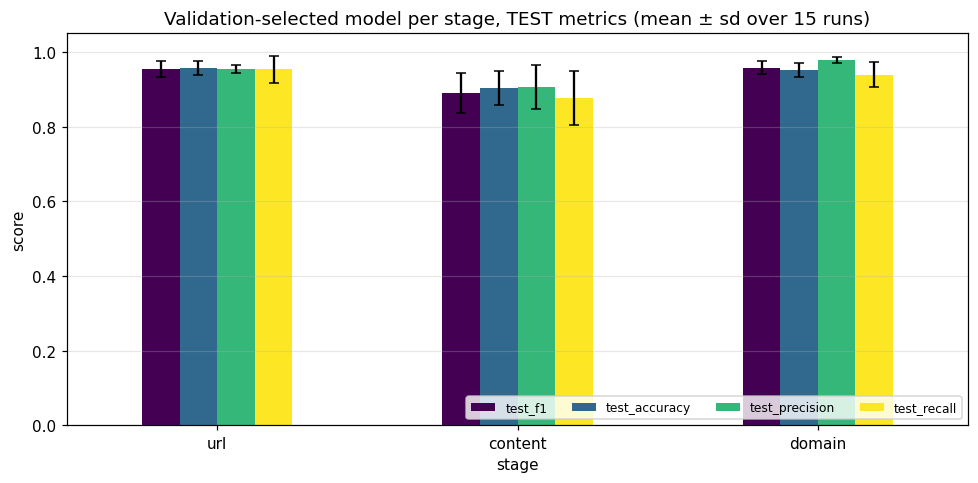

In [28]:
REPORT_COLS = ["test_precision", "test_recall", "test_f1", "test_accuracy"]
per_stage_tables = {}
for stage in CASCADE_ORDER:
    sub = ZOO[ZOO.stage == stage]
    tab = fmt_pm(sub, "model", REPORT_COLS)
    tab.columns = [c.replace("test_", "") for c in tab.columns]
    tab["val_f1"] = sub.groupby("model", sort=False)["val_f1"].mean().round(4)
    tab["sel_on_val"] = sub.groupby("model", sort=False)["selected"].sum().astype(int)
    tab = tab.sort_values("val_f1", ascending=False)
    per_stage_tables[stage] = tab
    # selection optimism: best model ON TEST vs the model VALIDATION actually picked
    opt = [g["test_f1"].max() - g[g.selected].iloc[0]["test_f1"] for _, g in sub.groupby(["seed", "fold"])]
    print(f"\n===== {stage}  (winner on val: {dict(Counter(sub[sub.selected]['model']))}) =====")
    print(tab.to_string())
    print(f"  model-selection optimism (best-on-test - val-picked): mean={np.mean(opt):.4f} max={np.max(opt):.4f}")
    agg_stats(sub, "model", REPORT_COLS).to_csv(f"{OUT_DIR}/nb_model_comparison_{stage}.csv")

# selected-model summary across runs, with error bars
sel_rows = ZOO[ZOO.selected]
fig, ax = plt.subplots(figsize=(9, 4.5))
m = agg_stats(sel_rows, "stage", ["test_precision", "test_recall", "test_f1", "test_accuracy"])
BARS = ["test_f1", "test_accuracy", "test_precision", "test_recall"]
err = m.loc[CASCADE_ORDER, [f"{c}_sd" for c in BARS]]
err.columns = BARS
m.loc[CASCADE_ORDER, BARS].plot(kind="bar", ax=ax, rot=0, colormap="viridis", ylim=(0, 1.05),
                                yerr=err, capsize=3)
ax.set_title(f"Validation-selected model per stage, TEST metrics (mean ± sd over {len(RESULTS)} runs)")
ax.set_xlabel("stage"); ax.set_ylabel("score"); ax.grid(axis="y", alpha=0.3)
ax.legend(loc="lower right", ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

## Full-pass fusion vs single stages

Full-pass runs every stage and decides from the aggregate (no early exit); single-stage decides from
one stage's `P(phish) >= 0.5`. Both scored on TEST, over every run. The aggregation rule the cascade
uses is the one VALIDATION picked in each run (`AGGSEL` records the validation ranking).

Full-pass fusion vs single stages on TEST (mean ± sd over 15 runs):
                        precision         recall             f1       accuracy                fp                 fn    mean_latency_ms
system                                                                                                                                
url-only            0.954 ± 0.010  0.954 ± 0.036  0.953 ± 0.021  0.957 ± 0.018    44.467 ± 9.906    44.000 ± 34.430     13.450 ± 0.000
content-only        0.905 ± 0.059  0.786 ± 0.112  0.838 ± 0.071  0.861 ± 0.059   81.533 ± 54.125  203.267 ± 106.712    856.790 ± 0.000
domain-only         0.978 ± 0.008  0.928 ± 0.046  0.952 ± 0.026  0.957 ± 0.022    20.133 ± 6.717    68.200 ± 43.898   2936.580 ± 0.000
full-pass (mean)    0.989 ± 0.007  0.958 ± 0.035  0.973 ± 0.021  0.976 ± 0.018     9.667 ± 6.091    40.067 ± 32.908  3749.325 ± 22.677
full-pass (median)  0.989 ± 0.004  0.958 ± 0.038  0.973 ± 0.021  0.976 ± 0.018    10.067 ± 3.348    39.800 ± 35.698  3749.

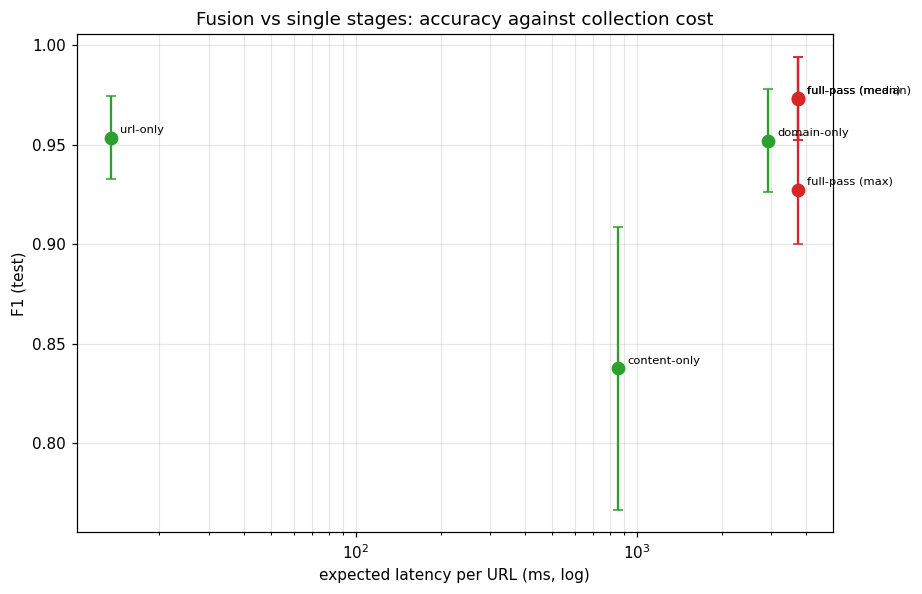

In [29]:
SINGLE  = [f"{s}-only" for s in CASCADE_ORDER]
FULL    = [f"full-pass ({a})" for a in AGGREGATIONS]
COLS    = ["precision", "recall", "f1", "accuracy", "fp", "fn", "mean_latency_ms"]

fusion_tbl = fmt_pm(SYSTEMS[SYSTEMS.system.isin(SINGLE + FULL)], "system", COLS)
print(f"Full-pass fusion vs single stages on TEST (mean ± sd over {len(RESULTS)} runs):")
print(fusion_tbl.to_string())
print("\nvalidation ranking of the aggregation rule (how often each won):")
print(AGGSEL.sort_values("f1", ascending=False).groupby(["seed", "fold"]).head(1)["aggregation"]
      .value_counts().to_string())
agg_stats(SYSTEMS, "system", COLS).to_csv(f"{OUT_DIR}/nb_systems.csv")

best_single = agg_stats(SYSTEMS[SYSTEMS.system.isin(SINGLE)], "system", ["f1"])["f1"].max()
best_full   = agg_stats(SYSTEMS[SYSTEMS.system.isin(FULL)], "system", ["f1"])["f1"].max()
print(f"\nbest single stage F1 = {best_single:.4f} | best full-pass F1 = {best_full:.4f} "
      f"-> fusion gains {best_full - best_single:+.4f} F1")

# accuracy vs cost, with sd whiskers on F1
st = agg_stats(SYSTEMS[SYSTEMS.system.isin(SINGLE + FULL)], "system", ["f1", "mean_latency_ms"])
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for name, r in st.iterrows():
    c = "tab:red" if name.startswith("full-pass") else "tab:green"
    ax.errorbar(r["mean_latency_ms"], r["f1"], yerr=r["f1_sd"], fmt="o", color=c, capsize=3, ms=8)
    ax.annotate(name, (r["mean_latency_ms"], r["f1"]), fontsize=7.5, xytext=(6, 3), textcoords="offset points")
ax.set_xscale("log"); ax.set_xlabel("expected latency per URL (ms, log)"); ax.set_ylabel("F1 (test)")
ax.set_title("Fusion vs single stages: accuracy against collection cost")
ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## The shared-margin deferral band

One margin `delta` applied to every stage, swept from `0` (URL stage decides everything) to `0.5`
(the band covers `[0, 1]`, nothing exits early, the verdict is always the fused aggregate). Curves are
the mean over runs, ribbons ±1 sd, so the width of the ribbon *is* the answer to "which of these
differences is signal".

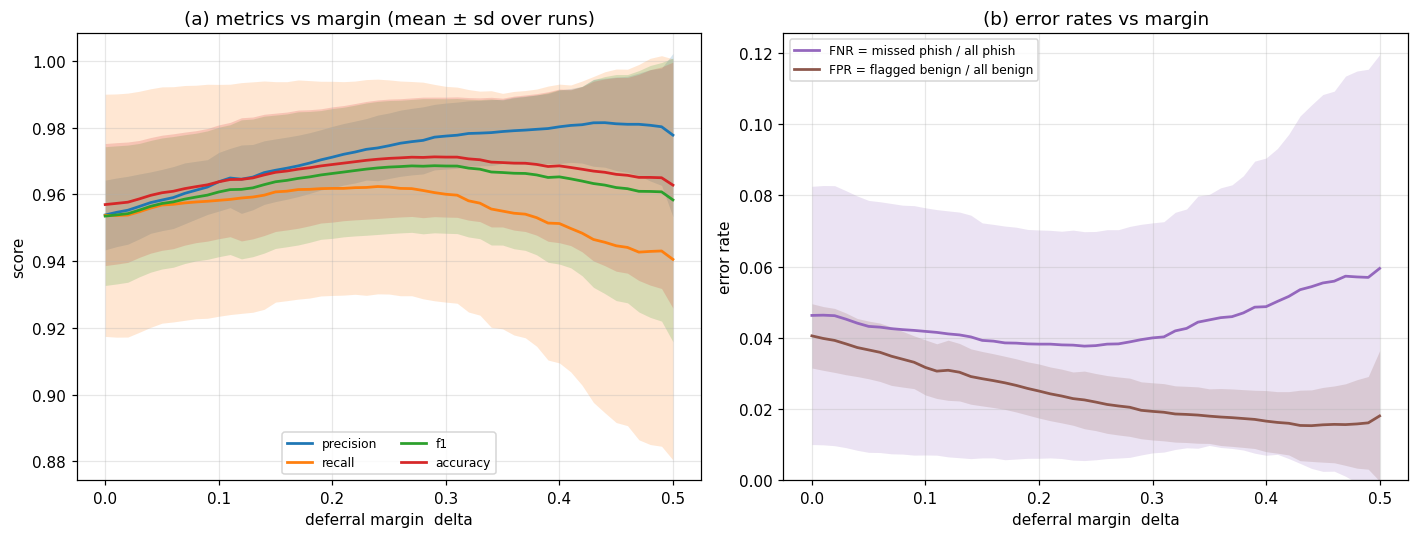

delta=0 (url only)  : F1=0.9535 ± 0.0208  P=0.9538  R=0.9537  @ 13 ms
delta->0.5 (fusion) : F1=0.9583 ± 0.0425  P=0.9777  R=0.9405  @ 2643 ms
best shared margin  : delta=0.29  F1=0.9686 ± 0.0201  @ 163 ms

at delta=0.50 the band covers [0, 1], yet 34.3% of URLs still exit early because a stage emitted exactly 0.0 or 1.0;
true full fusion (every stage on every URL) scores F1=0.9732 at 3749 ms.


In [30]:
MET = [("precision", "tab:blue"), ("recall", "tab:orange"), ("f1", "tab:green"), ("accuracy", "tab:red")]
band_cur = curve(BAND, "delta", ["precision", "recall", "f1", "accuracy", "fnr", "fpr",
                                 "mean_latency_ms", "fp", "fn"])
band_cur.to_csv(f"{OUT_DIR}/nb_band_delta_sweep.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for m, c in MET:
    band_plot(axes[0], band_cur, "delta", m, c, m)
axes[0].set_xlabel("deferral margin  delta"); axes[0].set_ylabel("score")
axes[0].set_title("(a) metrics vs margin (mean ± sd over runs)")
axes[0].grid(alpha=0.3); axes[0].legend(loc="lower center", ncol=2, fontsize=8)
for m, c in [("fnr", "tab:purple"), ("fpr", "tab:brown")]:
    band_plot(axes[1], band_cur, "delta", m, c,
              "FNR = missed phish / all phish" if m == "fnr" else "FPR = flagged benign / all benign")
axes[1].set_xlabel("deferral margin  delta"); axes[1].set_ylabel("error rate")
axes[1].set_ylim(bottom=0); axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
axes[1].set_title("(b) error rates vs margin")
plt.tight_layout(); plt.show()

lo, hi = band_cur.iloc[0], band_cur.iloc[-1]
print(f"delta=0 (url only)  : F1={lo.f1:.4f} ± {lo.f1_sd:.4f}  P={lo.precision:.4f}  R={lo.recall:.4f}"
      f"  @ {lo.mean_latency_ms:.0f} ms")
print(f"delta->0.5 (fusion) : F1={hi.f1:.4f} ± {hi.f1_sd:.4f}  P={hi.precision:.4f}  R={hi.recall:.4f}"
      f"  @ {hi.mean_latency_ms:.0f} ms")
best = band_cur.loc[band_cur["f1"].idxmax()]
print(f"best shared margin  : delta={best.delta:.2f}  F1={best.f1:.4f} ± {best.f1_sd:.4f}"
      f"  @ {best.mean_latency_ms:.0f} ms")

# delta=0.5 is NOT literally full fusion: the band is [0, 1] and the production rule exits on
# p <= lo or p >= hi, so a tree ensemble emitting exactly 0.0 or 1.0 still exits early. True full
# fusion is the full-pass row of the previous section; both are marked on the frontier below.
_end = COMP[np.isclose(COMP["delta"], DELTAS[-1])]
_sat = 100 * sum(_end[f"{k}_{p}"].sum() for k in ("phish", "benign")
                 for p in CASCADE_ORDER) / _end["n"].sum()
FULL_F1  = float(st.loc["full-pass (mean)", "f1"])
FULL_LAT = float(st.loc["full-pass (mean)", "mean_latency_ms"])
print(f"\nat delta={DELTAS[-1]:.2f} the band covers [0, 1], yet {_sat:.1f}% of URLs still exit early "
      f"because a stage emitted exactly 0.0 or 1.0;\ntrue full fusion (every stage on every URL) "
      f"scores F1={FULL_F1:.4f} at {FULL_LAT:.0f} ms.")

### Where URLs leave the cascade

Exit composition across the same sweep, split by the verdict the cascade returned. Counts are
averaged over runs and shown as a share of each run's test split, so folds of slightly different size
stay comparable.

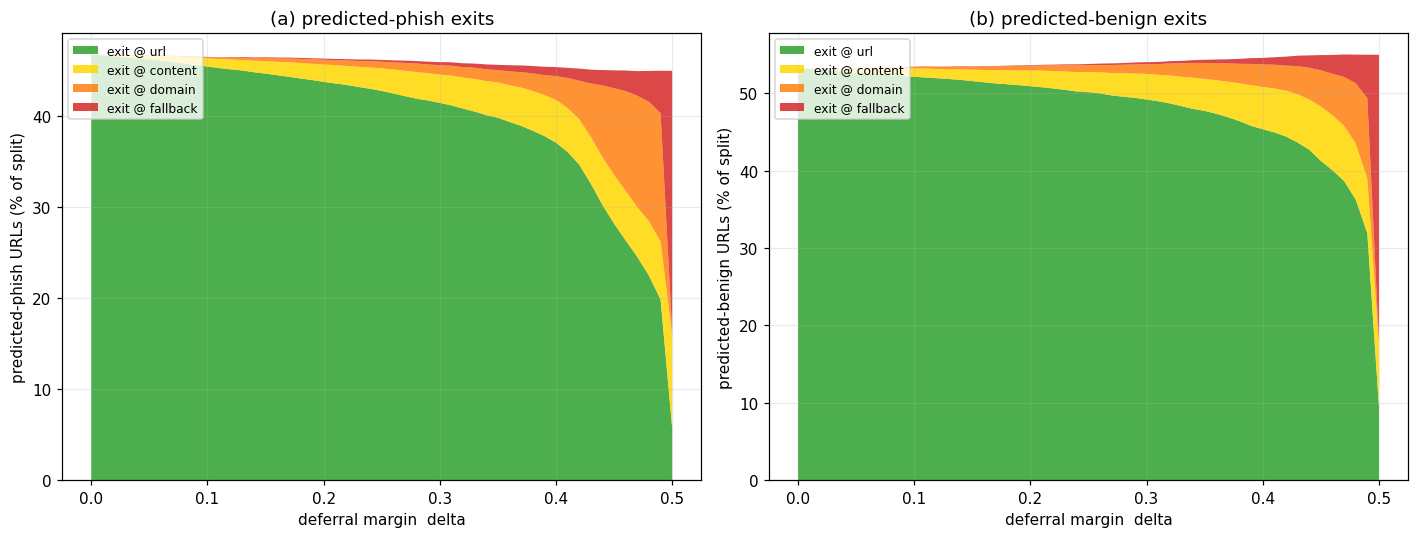

at delta=0.30: 90.7% of URLs are settled by the url stage alone (1 in 10.7 escalates)


In [31]:
comp_cur = COMP.groupby("delta", sort=False).mean(numeric_only=True).reset_index()
for kind in ("phish", "benign"):
    for p in EXIT_POINTS:
        comp_cur[f"{kind}_{p}_share"] = 100 * comp_cur[f"{kind}_{p}"] / comp_cur["n"]
comp_cur.to_csv(f"{OUT_DIR}/nb_band_exit_composition.csv", index=False)

EXIT_COLORS = ["tab:green", "gold", "tab:orange", "tab:red"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for ax, kind, ylab in [(axes[0], "phish", "predicted-phish URLs (% of split)"),
                       (axes[1], "benign", "predicted-benign URLs (% of split)")]:
    ax.stackplot(comp_cur["delta"], *[comp_cur[f"{kind}_{p}_share"] for p in EXIT_POINTS],
                 labels=[f"exit @ {p}" for p in EXIT_POINTS], colors=EXIT_COLORS, alpha=0.85)
    ax.set_xlabel("deferral margin  delta"); ax.set_ylabel(ylab)
    ax.grid(alpha=0.25); ax.legend(loc="upper left", fontsize=8)
axes[0].set_title("(a) predicted-phish exits"); axes[1].set_title("(b) predicted-benign exits")
plt.tight_layout(); plt.show()

_at = comp_cur.iloc[(comp_cur["delta"] - 0.3).abs().idxmin()]
_url_share = 100 * (_at["phish_url"] + _at["benign_url"]) / _at["n"]
print(f"at delta=0.30: {_url_share:.1f}% of URLs are settled by the url stage alone "
      f"(1 in {100 / max(100 - _url_share, 1e-9):.1f} escalates)")

### Accuracy against collection cost

The frontier the cascade buys: F1 against expected per-URL latency as the margin widens. Horizontal
whiskers are the sd of the expected cost across runs, vertical whiskers the sd of F1.

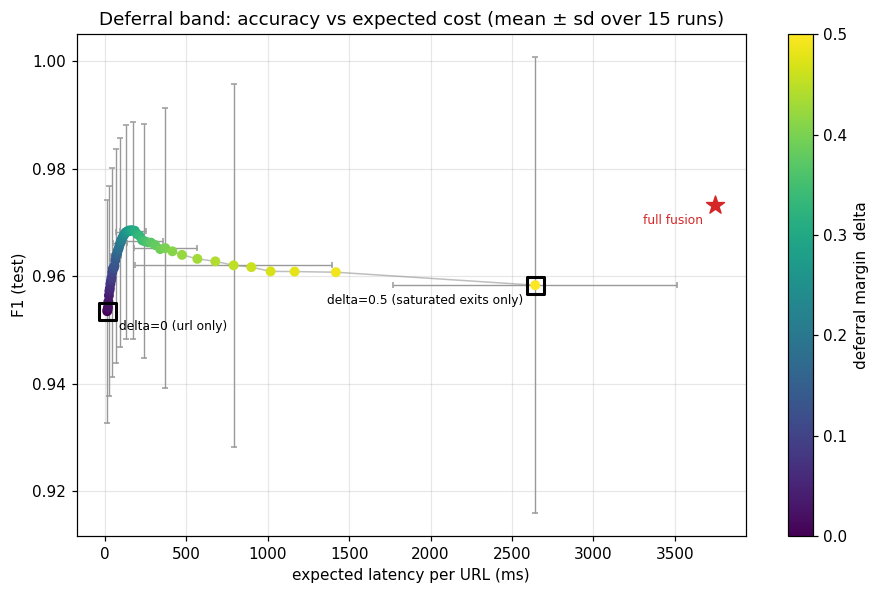

In [32]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(band_cur["mean_latency_ms"], band_cur["f1"], color="tab:gray", alpha=0.5, lw=1, zorder=2)
every = band_cur.iloc[::5]
ax.errorbar(every["mean_latency_ms"], every["f1"], xerr=every["mean_latency_ms_sd"],
            yerr=every["f1_sd"], fmt="none", ecolor="0.6", elinewidth=0.9, capsize=2, zorder=3)
sc = ax.scatter(band_cur["mean_latency_ms"], band_cur["f1"], c=band_cur["delta"], cmap="viridis",
                s=30, zorder=4)
fig.colorbar(sc, ax=ax, label="deferral margin  delta")
ax.scatter([FULL_LAT], [FULL_F1], s=150, marker="*", color="tab:red", zorder=6,
           label="full fusion (every stage, every URL)")
ax.annotate("full fusion", (FULL_LAT, FULL_F1), fontsize=8, ha="right",
            xytext=(-8, -12), textcoords="offset points", color="tab:red")
for i, lab, ha, dx in [(0, "delta=0 (url only)", "left", 8),
                       (-1, "delta=0.5 (saturated exits only)", "right", -8)]:
    ax.scatter([band_cur["mean_latency_ms"].iloc[i]], [band_cur["f1"].iloc[i]], s=120, marker="s",
               edgecolor="black", facecolor="none", lw=2, zorder=5)
    ax.annotate(lab, (band_cur["mean_latency_ms"].iloc[i], band_cur["f1"].iloc[i]), fontsize=8,
                ha=ha, xytext=(dx, -12), textcoords="offset points")
ax.set_xlabel("expected latency per URL (ms)"); ax.set_ylabel("F1 (test)")
ax.set_title(f"Deferral band: accuracy vs expected cost (mean ± sd over {len(RESULTS)} runs)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Per-stage margins chosen on validation

The grid over `(delta_url, delta_content, delta_domain)` is swept on **VALIDATION**; within each
latency budget the F1-best combination is kept and then scored **once** on TEST. Three columns are
worth reading together:

* `f1` -- what the nested protocol reports;
* `oracle_test_f1` -- what the **old** protocol would have reported (best config picked on test);
* `optimism` -- the difference, i.e. how much of the old headline was selection on the reported split.

`triples` shows how often the *same* margin triple is re-selected across runs: if it moves around, the
specific numbers in the shipped configuration are not the point, the budget is.

In [33]:
PICK_COLS = ["d_url", "d_content", "d_domain", "val_f1", "f1", "precision", "recall",
             "fp", "fn", "test_latency_ms", "oracle_test_f1", "optimism", "n_tied_on_val"]
picks_tbl = fmt_pm(PICKS, "budget_ms", PICK_COLS)
print(f"Per-stage margins selected on VALIDATION, scored on TEST (mean ± sd over {len(RESULTS)} runs):")
print(picks_tbl.to_string())
agg_stats(PICKS, "budget_ms", PICK_COLS).to_csv(f"{OUT_DIR}/nb_band_budget_picks.csv")

print("\nselected triples per budget (frequency across runs):")
_t = PICKS.assign(triple=lambda d: d.apply(
    lambda r: f"({r.d_url:.2f},{r.d_content:.2f},{r.d_domain:.2f})", axis=1))
for b, sub in _t.groupby("budget_ms"):
    print(f"  {b:5} ms: {dict(Counter(sub['triple']).most_common(3))}"
          f"{' ...' if sub['triple'].nunique() > 3 else ''}")

print(f"\nshipped configuration ({SHIPPED_LABEL}) scored as a fixed point on every run:")
print(fmt_pm(SYSTEMS[SYSTEMS.system == SHIPPED_LABEL], "system",
             ["precision", "recall", "f1", "fp", "fn", "mean_latency_ms"]).to_string())

# exit split at the shipped budget
_sb = PICKS[PICKS.budget_ms == SHIPPED_BUDGET]
_shares = {p: 100 * _sb[f"exit_{p}"].sum() / _sb[[f"exit_{q}" for q in EXIT_POINTS]].to_numpy().sum()
           for p in EXIT_POINTS}
print(f"\nexit split at the {SHIPPED_BUDGET} ms budget: "
      + "  ".join(f"{p}={v:.1f}%" for p, v in _shares.items())
      + f"  ->  1 in {100 / max(100 - _shares['url'], 1e-9):.1f} URLs escalates past the url stage")

Per-stage margins selected on VALIDATION, scored on TEST (mean ± sd over 15 runs):
                   d_url      d_content       d_domain         val_f1             f1      precision         recall              fp               fn    test_latency_ms oracle_test_f1        optimism      n_tied_on_val
budget_ms                                                                                                                                                                                                               
50         0.188 ± 0.094  0.075 ± 0.133  0.010 ± 0.031  0.978 ± 0.012  0.965 ± 0.018  0.969 ± 0.007  0.961 ± 0.032  29.867 ± 6.653  36.800 ± 30.482    74.277 ± 39.152  0.963 ± 0.020  -0.001 ± 0.005  588.667 ± 849.151
100        0.291 ± 0.098  0.132 ± 0.144  0.055 ± 0.133  0.983 ± 0.010  0.968 ± 0.019  0.975 ± 0.008  0.961 ± 0.034  23.333 ± 7.451  37.133 ± 32.047   133.852 ± 65.733  0.970 ± 0.020   0.002 ± 0.004  525.533 ± 864.369
250        0.363 ± 0.088  0.265 ± 0.164  0.175 ± 

## Legacy one-sided threshold baseline

The engine's production cascade is the two-sided band above; this section keeps the older
**one-sided** rule (a stage exits only upwards, `p >= threshold`, so a confidently-benign URL can never
exit early) as a reference curve, now measured under the same repeated protocol. It is not the shipped
design and no operating point is selected from it.

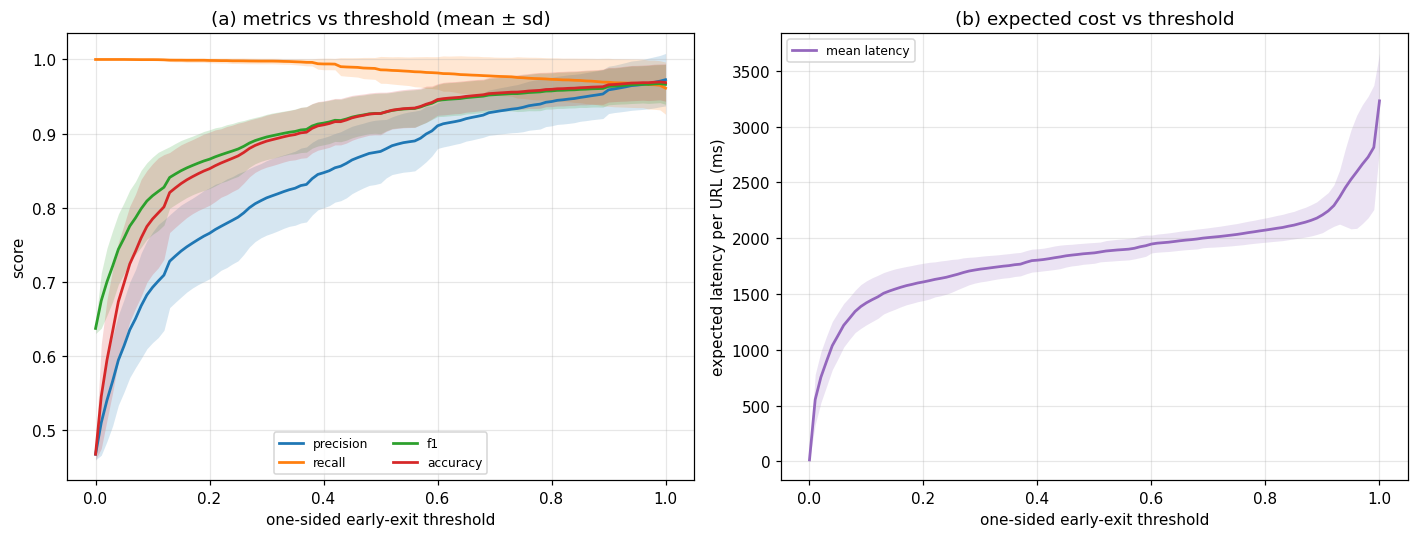

best one-sided threshold: 0.99 -> F1=0.9674 ± 0.0256 @ 2814 ms   (two-sided band best: F1=0.9686)


In [34]:
one_cur = curve(ONESIDED, "threshold", ["precision", "recall", "f1", "accuracy", "fnr", "fpr",
                                        "mean_latency_ms"])
one_cur.to_csv(f"{OUT_DIR}/nb_onesided_threshold_sweep.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for m, c in MET:
    band_plot(axes[0], one_cur, "threshold", m, c, m)
axes[0].set_xlabel("one-sided early-exit threshold"); axes[0].set_ylabel("score")
axes[0].set_title("(a) metrics vs threshold (mean ± sd)"); axes[0].grid(alpha=0.3)
axes[0].legend(loc="lower center", ncol=2, fontsize=8)
band_plot(axes[1], one_cur, "threshold", "mean_latency_ms", "tab:purple", "mean latency")
axes[1].set_xlabel("one-sided early-exit threshold"); axes[1].set_ylabel("expected latency per URL (ms)")
axes[1].set_title("(b) expected cost vs threshold"); axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

_b = one_cur.loc[one_cur["f1"].idxmax()]
print(f"best one-sided threshold: {_b.threshold:.2f} -> F1={_b.f1:.4f} ± {_b.f1_sd:.4f} "
      f"@ {_b.mean_latency_ms:.0f} ms   (two-sided band best: F1={band_cur['f1'].max():.4f})")

## Export figures

Figures are written to `FIGDIR` (`eval_results/nested/figs` by default) rather than straight into the
thesis or paper image directories, because the numbers they carry differ from the ones those documents
currently cite. Point `FIGDIR` at `Master_Thesis/img/results` or `WTMC_Paper/img/results` once the text
has been updated to the nested protocol.

In [35]:
os.makedirs(FIGDIR, exist_ok=True)
def _save(fig, name):
    p = os.path.join(FIGDIR, name)
    fig.savefig(p, bbox_inches="tight"); plt.close(fig); print("saved ->", p)

def _metric_panel(ax, cur, x, xlabel, ribbons=True):
    for m, c in MET:
        if ribbons:
            band_plot(ax, cur, x, m, c, m)
        else:
            ax.plot(cur[x], cur[m], color=c, label=m, lw=1.8)
    ax.set_xlabel(xlabel); ax.set_ylabel("score"); ax.grid(alpha=0.3)
    ax.legend(loc="lower center", ncol=2, fontsize=8)

def _error_panel(ax, cur, x, xlabel):
    band_plot(ax, cur, x, "fnr", "tab:purple", "FNR = missed phish / all phish")
    band_plot(ax, cur, x, "fpr", "tab:brown", "FPR = flagged benign / all benign")
    ax.set_xlabel(xlabel); ax.set_ylabel("error rate"); ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3); ax.legend(loc="upper right", fontsize=8)

def _pareto_fig(cur, label, name, full_point=None, height=5):
    fig, ax = plt.subplots(figsize=(6.5, height))
    ax.plot(cur["mean_latency_ms"], cur["f1"], color="tab:gray", alpha=0.5, lw=1, zorder=2)
    ev = cur.iloc[::5]
    ax.errorbar(ev["mean_latency_ms"], ev["f1"], xerr=ev["mean_latency_ms_sd"], yerr=ev["f1_sd"],
                fmt="none", ecolor="0.6", elinewidth=0.9, capsize=2, zorder=3)
    sc = ax.scatter(cur["mean_latency_ms"], cur["f1"], c=cur[cur.columns[0]], cmap="viridis", s=26, zorder=4)
    fig.colorbar(sc, ax=ax, label=label)
    if full_point is not None:
        ax.scatter([full_point[0]], [full_point[1]], s=150, marker="*", color="tab:red", zorder=6)
        ax.annotate("full fusion", full_point, fontsize=8, ha="right", xytext=(-8, -12),
                    textcoords="offset points", color="tab:red")
    for i, lab, ha, dx in [(0, "url only", "left", 8), (-1, "δ=0.5", "right", -8)]:
        ax.scatter([cur["mean_latency_ms"].iloc[i]], [cur["f1"].iloc[i]], s=110, marker="s",
                   edgecolor="black", facecolor="none", lw=2, zorder=5)
        ax.annotate(lab, (cur["mean_latency_ms"].iloc[i], cur["f1"].iloc[i]), fontsize=8, ha=ha,
                    xytext=(dx, -12), textcoords="offset points")
    ax.set_xlabel("expected latency per URL (ms)"); ax.set_ylabel("F1 (test)"); ax.grid(alpha=0.3)
    fig.tight_layout(); _save(fig, name)

# (1) paper Fig 2 -- single-column metrics vs margin, mean lines only (no sd ribbons),
#     at the height the paper's page layout was fitted with
fig, ax = plt.subplots(figsize=(6.5, 3.8))
_metric_panel(ax, band_cur, "delta", "deferral margin  δ", ribbons=False)
fig.tight_layout(); _save(fig, "band_sweep_metrics.pdf")

# (2) thesis two-panel: metrics | error rates vs margin
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
_metric_panel(axes[0], band_cur, "delta", "deferral margin  δ"); axes[0].set_title("(a) metrics vs margin")
_error_panel(axes[1], band_cur, "delta", "deferral margin  δ"); axes[1].set_title("(b) error rates vs margin")
fig.tight_layout(); _save(fig, "band_sweep.pdf")

# (3) paper Fig 3 -- exit composition (shares)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for ax, kind, ylab in [(axes[0], "phish", "predicted-phish URLs (% of split)"),
                       (axes[1], "benign", "predicted-benign URLs (% of split)")]:
    ax.stackplot(comp_cur["delta"], *[comp_cur[f"{kind}_{p}_share"] for p in EXIT_POINTS],
                 labels=[f"exit @ {p}" for p in EXIT_POINTS], colors=EXIT_COLORS, alpha=0.85)
    ax.set_xlabel("deferral margin  δ"); ax.set_ylabel(ylab); ax.grid(alpha=0.25)
    ax.legend(loc="upper left", fontsize=8)
axes[0].set_title("(a) predicted-phish exits"); axes[1].set_title("(b) predicted-benign exits")
fig.tight_layout(); _save(fig, "composition_band.pdf")

# (4) paper Fig 4 -- accuracy-cost frontier, without the full-fusion marker, at the height the
#     paper's page layout was fitted with
_pareto_fig(band_cur, "deferral margin  δ", "pareto_band.pdf", height=4.0)

# (5) fusion vs single stages
fig, ax = plt.subplots(figsize=(7.5, 5))
for name, r in st.iterrows():
    c = "tab:red" if name.startswith("full-pass") else "tab:green"
    ax.errorbar(r["mean_latency_ms"], r["f1"], yerr=r["f1_sd"], fmt="o", color=c, capsize=3, ms=8)
    ax.annotate(name, (r["mean_latency_ms"], r["f1"]), fontsize=7.5, xytext=(6, 3), textcoords="offset points")
ax.set_xscale("log"); ax.set_xlabel("expected latency per URL (ms, log)"); ax.set_ylabel("F1 (test)")
ax.grid(alpha=0.3, which="both"); fig.tight_layout(); _save(fig, "fusion_vs_single.pdf")

# (6) legacy one-sided reference
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
_metric_panel(axes[0], one_cur, "threshold", "early-exit threshold"); axes[0].set_title("(a) metrics vs threshold")
_error_panel(axes[1], one_cur, "threshold", "early-exit threshold"); axes[1].set_title("(b) error rates vs threshold")
fig.tight_layout(); _save(fig, "onesided_sweep.pdf")
_pareto_fig(one_cur, "early-exit threshold", "pareto_onesided.pdf")

print(f"\nfigures -> {FIGDIR}/   tables -> {OUT_DIR}/")

saved -> eval_results/nested/figs/band_sweep_metrics.pdf
saved -> eval_results/nested/figs/band_sweep.pdf
saved -> eval_results/nested/figs/composition_band.pdf
saved -> eval_results/nested/figs/pareto_band.pdf
saved -> eval_results/nested/figs/fusion_vs_single.pdf
saved -> eval_results/nested/figs/onesided_sweep.pdf
saved -> eval_results/nested/figs/pareto_onesided.pdf

figures -> eval_results/nested/figs/   tables -> eval_results/nested/
